In [1]:
import glob, os, pdfplumber, fitz
import re
from datetime import datetime
import nltk
nltk.download('punkt')
nltk.download('words')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet') 
nltk.download('omw-1.4')
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords, wordnet
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk import pos_tag

from textblob import TextBlob

import pandas as pd
from collections import Counter 
import requests
from bs4 import BeautifulSoup

import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import string
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\silvi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package words to
[nltk_data]     C:\Users\silvi\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\silvi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\silvi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\silvi\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\silvi\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_d

In [2]:
texts = []
# print(os.path.exists(r"DataScience/*.pdf"))
for file in glob.glob(r"Data\UkraineDocuments\*.pdf"):
    print(f"Reading {file}")
    doc = fitz.open(file)
    pages_text = []
    for page in doc:
       text = page.get_text()
       pages_text.append(text)
    texts.append(pages_text)
    doc.close()

Reading Data\UkraineDocuments\2024-03-20 OHCHR Report on Occupation and Aftermath_EN.pdf
Reading Data\UkraineDocuments\2024-03-26 OHCHR 38th Periodic Report.pdf
Reading Data\UkraineDocuments\2024-10-01 OHCHR 40th periodic report on Ukraine.pdf
Reading Data\UkraineDocuments\2025-03-21 OHCHR Report on Children's Rights in Ukraine.pdf
Reading Data\UkraineDocuments\2025-06-30 OHCHR 42nd periodic report on Ukraine_2.pdf
Reading Data\UkraineDocuments\2025-09-22 Treatment of civilians_ENG.pdf
Reading Data\UkraineDocuments\23-12-12-OHCHR-37th-periodic-report-ukraine-en.pdf
Reading Data\UkraineDocuments\A_77_220-EN.pdf
Reading Data\UkraineDocuments\A_78_340-EN.pdf
Reading Data\UkraineDocuments\A_79_258-EN.pdf
Reading Data\UkraineDocuments\A_HRC_53_64-EN.pdf
Reading Data\UkraineDocuments\A_HRC_59_67 ENG.pdf
Reading Data\UkraineDocuments\N2312781.pdf
Reading Data\UkraineDocuments\N2411029.pdf
Reading Data\UkraineDocuments\n2521410.pdf


In [3]:
# Cleaning the texts
for j in range(len(texts)):
    if j in [7,8,9,10,11,14]:   # National assembly reports first pages removal of unnecessary information
        texts[j][0] = re.split(r'Summary', texts[j][0])[-1]
    if j in [12, 13]:  # Reports by Security Council first pages removal of unnecessary information
        texts[j][0] = re.split(r'Report of the Secretary-General', texts[j][0])[-1]
    for i in range(len(texts[j])):
        if j in [0,1,2,3,4,5,6,10,11]:  # Remove notes from texts by United Nations Human Rights Office of the High Commisioner and A/HRC documents
            texts[j][i] = re.split(r'\n \n\d+', texts[j][i])[0]
            texts[j][i] = re.sub(r'Report on the Russian Occupation of Ukraine and its Aftermath','', texts[j][i])
            texts[j][i] = re.sub(r'\.{2,}','', texts[j][i])
        texts[j][i] = re.split(r'\n__________________ \n', texts[j][i])[0]
        texts[j][i] = re.split(r'\n__________________ \n', texts[j][i])[0]
        texts[j][i] = re.sub(r'/d+-/d+', '', texts[j][i])
        texts[j][i] = re.sub(r'\s+',' ', texts[j][i]).strip()
        texts[j][i] = re.sub(r'[*“”|©@#$%]', '',texts[j][i])
        texts[j][i] = re.sub(r'\d+\.', '',texts[j][i])
        texts[j][i] = re.sub(r'\d+', '',texts[j][i])
        texts[j][i] = re.sub(r'\(\s*\)', '', texts[j][i])
        texts[j][i] = re.sub(r'A//', '',texts[j][i])
        texts[j][i] = re.sub(r'/', '',texts[j][i])
        texts[j][i] = re.sub(r' \- ', '',texts[j][i])
        texts[j][i] = re.sub(r'\b[IVXLCDM]+\.', '', texts[j][i])
        texts[j][i] = re.sub(r'\([a-zA-Z]\)\s*', '', texts[j][i])
        texts[j][i] = re.sub(r'\s+',' ', texts[j][i]).strip()
        texts[j][i] = texts[j][i].strip()
for k in range(len(texts)):
    texts[k] = [x for x in texts[k] if x.strip()] 
    
# Specific problems for some documents: 
texts[0][31] = re.split(r"of collectivisation of agriculture", texts[0][31])[0]

In [4]:
titles = [
    'HUMAN RIGHTS SITUATION DURING THE RUSSIAN OCCUPATION OF TERRITORY OF UKRAINE AND ITS AFTERMATH 24 February 2022 – 31 December 2023',
    'REPORT ON THE HUMAN RIGHTS SITUATION IN UKRAINE 1 December 2023 – 29 February 2024',
    'TREATMENT OF PRISONERS OF WAR AND UPDATE ON THE HUMAN RIGHTS SITUATION IN UKRAINE 1 June to 31 August 2024',
    'THE IMPACT OF THE ARMED CONFLICT AND OCCUPATION ON CHILDREN’S RIGHTS IN UKRAINE 24 February 2022 — 31 December 2024',
    'REPORT ON THE HUMAN RIGHTS SITUATION IN UKRAINE 1 December 2024 – 31 May 2025',
    'TREATMENT OF CIVILIANS DEPRIVED OF THEIR LIBERTY IN THE CONTEXT OF THE ARMED ATTACK BY THE RUSSIAN FEDERATION AGAINST UKRAINE',
    'REPORT ON THE HUMAN RIGHTS SITUATION IN UKRAINE 1 August to 30 November 2023',
    'A/77/220 - 25 July 2022',
    'A/78/340 - 1 September 2023',
    'A/79/258 - 30 July 2024',
    'A/HRC/53/64 - 26 May 2023',
    'A/HRC/59/67 - 28 May 2025',
    'S/2023/413 - 22 June 2023',
    'S/2024/385 - 14 May 2024',
    'A/80/315 - 6 August 2025'
]
dates = [
    datetime(2024,3,20),
    datetime(2024,3,26),
    datetime(2024,10,1),
    datetime(2025,3,21),
    datetime(2025,6,30),
    datetime(2024,9,22),
    datetime(2023,12,12),
    datetime(2022,7,25),
    datetime(2023,9,1),
    datetime(2024,7,30),
    datetime(2023,5,26),
    datetime(2025,5,28),
    datetime(2023,6,22),
    datetime(2024,5,14),
    datetime(2025,8,6),
]

In [5]:
lemmatizer = WordNetLemmatizer()
def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith("J"):
        return nltk.corpus.wordnet.ADJ
    elif treebank_tag.startswith("V"):
        return nltk.corpus.wordnet.VERB
    elif treebank_tag.startswith("N"):
        return nltk.corpus.wordnet.NOUN
    elif treebank_tag.startswith("R"):
        return nltk.corpus.wordnet.ADV
    else:
        return nltk.corpus.wordnet.NOUN

rows = []
for i in range(len(texts)):
    text = ''.join(texts[i])
    sentences = nltk.sent_tokenize(text)
    words = [nltk.word_tokenize(sentence) for sentence in sentences]
    pos_tagged_words = [nltk.pos_tag(word_list) for word_list in words]
    lemmatized_words = []
    for sentence in pos_tagged_words:
        lemmatized_sentence = []
        for word, pos in sentence:
            lemmatized_word = lemmatizer.lemmatize(word.lower(), get_wordnet_pos(pos))
            lemmatized_sentence.append((lemmatized_word, pos))
        lemmatized_words.extend(lemmatized_sentence)
    stop_words = set(nltk.corpus.stopwords.words('english'))
    custom_stop_words = set({
    "access","address","affect","aid","area","assistance","authority",
    "case","community","council","crisis","delegate","discuss","emphasize",
    "express","further","government","ground","highlight","humanitarian",
    "include","information","international","issue","mandate","mechanism",
    "meeting","monitoring", "moscow","need","note","ohchr","ongoing", 
    "one","party","provide","public","region","remark","report","representative",
    "response","russia","russian","security","security council","session",
    "situation","statement","stress","support","territory","ukraine","ukrainian",
    "underscore","un","urge","welcome", "federation", "crimea","crimean",
    "donetsk","kherson","zaporizhzhia","kharkiv","pow","conflictrelated",
    "ihl","temporarily","republic","federation"})
    stop_words.update(custom_stop_words)
    filtered_words = [(word,pos) for word, pos in lemmatized_words if word not in stop_words] 
    final_filtered_words = []
    for word,pos in filtered_words:
        cleaned_word = re.sub(r'[^a-zA-Z0-9\s]','', word)
        if cleaned_word:
            final_filtered_words.append((cleaned_word,pos))
    all_words = [word for word, pos in final_filtered_words]
    most_common_words = Counter(all_words).most_common(10)
    processed_text = " ".join(all_words)
    nouns = [word for word,pos in final_filtered_words if pos.startswith('NN')]
    verbs = [word for word,pos in final_filtered_words if pos.startswith('VB')]
    adjectives = [word for word,pos in final_filtered_words if pos.startswith('JJ')]
    most_common_nouns = Counter(nouns).most_common(10)
    most_common_verbs = Counter(verbs).most_common(10)
    most_common_adjectives = Counter(adjectives).most_common(10)
    rows.append({
        'Title' : titles[i],
        'Date': dates[i],
        'Text': text, 
        'Tokenized sentences': sentences, 
        'Tokenized words': words,
        'Lemmatized words': lemmatized_words, 
        'Filtered words': final_filtered_words, 
        'Processed text': processed_text,
        'Most Common words': most_common_words,
        'Nouns': nouns, 
        'Most Common Nouns': most_common_nouns,
        'Verbs': verbs, 
        'Most Common verbs': most_common_verbs, 
        'Adjectives': adjectives, 
        'Most Common Adjective': most_common_adjectives
    })
dataframe_Ukraine = pd.DataFrame(rows).sort_values(by='Date')

In [6]:
# Scraping - run only if you don't already have the gaza folder from the Gaza-Israel notebook
base_url = "https://www.ohchr.org/en/documents-listing"
headers = { "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0 Safari/537.36" }

print(f"\n🌍 Scraping for Gaza...\n")
    
params = {
    f"field_geolocation_target_id[1081]": 1081,
    "field_content_category_target_id[180]": 180,
    "field_content_category_target_id[182]": 182,
    "field_entity_target_id[1349]": 1349,
    "field_entity_target_id[1350]": 1350,
    "view_mode": "document-list",
    "sort_bef_combine": "field_published_date_value_DESC"
}

links = []
page = 0
while True:
    params["page"] = page
    response = requests.get(base_url, params=params, headers=headers)
    if response.status_code != 200:
        break

    soup = BeautifulSoup(response.text, "html.parser")
    cards = soup.find_all("a", class_="card-2__link", href=True)
    page_links = []

    for a in cards:
        text = a.get_text(strip=True)
        href = a["href"]
        if "A/" in text or "a/" in href.lower():
            full_url = "https://www.ohchr.org" + href
            page_links.append(full_url)

    if not page_links:
        break

    links.extend(page_links)
    page += 1

# Downloading the files
def extract_code(link):
    match = re.search(r"ahrc(\d{4})(?:-|$)", link, re.IGNORECASE) # 1. Format A/HRC/XX/YY (ex: ahrc5669 → A/HRC/56/69)
    if match:
        digits = match.group(1)
        return f"A/HRC/{digits[:2]}/{digits[2:]}"
    
    match = re.search(r"ahrc(\d{5})(?:-|$)", link, re.IGNORECASE) # 2. Format A/HRC/XX/YYY (ex: ahrc56699 → A/HRC/56/699)
    if match:
        digits = match.group(1)
        return f"A/HRC/{digits[:2]}/{digits[2:]}"
    
    match = re.search(r"ahrc(\d+)(crp|wp|res|add)(\d+)?", link, re.IGNORECASE) # 3. Format with suffix (ex: ahrc40crp3 → A/HRC/40/CRP.3)
    if match:
        session = match.group(1)
        suffix_type = match.group(2).upper()
        suffix_num = match.group(3) if match.group(3) else ""
        return f"A/HRC/{session}/{suffix_type}.{suffix_num}" if suffix_num else f"A/HRC/{session}/{suffix_type}"
    
    match = re.search(r"/a(\d{5})(?:-|$)", link, re.IGNORECASE) # 4. Format classic A/XX/YY (ex: a80315 → A/80/315)
    if match:
        digits = match.group(1)
        return f"A/{digits[:2]}/{digits[2:]}"
    
    return None


os.makedirs(f"docs/gaza", exist_ok=True)
codes = []
for link in links:
    code = extract_code(link)
    codes.append(code)
    if not code:
        print(f"⚠️ No code found in : {link}")

successful = len([c for c in codes if c])
for code in codes:
    pdf_url = f"https://documents.un.org/api/symbol/access?s={code}&l=en&t=pdf"
    try:
        response = requests.get(pdf_url)
        response.raise_for_status()

        filename = code.replace("/", "_") + ".pdf"
        filepath = os.path.join("docs", 'gaza', filename)

        with open(filepath, "wb") as f:
            f.write(response.content)
    except requests.HTTPError as e:
        print(f"⚠️ Unable to download {pdf_url}: {e}")


🌍 Scraping for Gaza...

⚠️ Unable to download https://documents.un.org/api/symbol/access?s=A/HRC/61/26&l=en&t=pdf: 404 Client Error: Not Found for url: https://documents.un.org/error


In [7]:
gaza_stopwords = [
    "access","address","affect","aid","area","assistance","authority","case",
    "community","council","crisis","delegate","discuss","emphasize","express",
    "further","government","ground","highlight","humanitarian","include","information",
    "international","issue","mandate","mechanism","meeting","monitoring","need",
    "note","ongoing", "one","party","provide","public","region","remark","report",
    "representative","response","security","session","situation","statement",
    "stress","support","territory","underscore","united nation","un","urge",
    "welcome","palestinian","israeli","israel","gaza","jerusalem","west","bank",
    "east","settler","settlement","outpost","demolition","eviction","commissioner",
    "accountability","yearold",'administrative',"restriction","permit","operation","shoot",
    "home","structure","business","movement","killing","police","forcible","policy"
]
stop_words = list(set(nltk.corpus.stopwords.words('english')))
gaza_stopwords.extend(stop_words)

In [8]:
def extract_metadata_from_first_page(page):
    metadata = {"symbol": None, "date": None, "summary": None}
    
    m = re.search(r'\b[ASE]\/[A-Z0-9][A-Z0-9\/\.\-]*\b', page) # 1. Symbol ONU : A/HRC/50/65 ou A/77/220 etc.
    if m:
        metadata["symbol"] = m.group(0)
    
    dates = re.findall(r'\b\d{1,2}\s+[A-Z][a-z]+\s+\d{4}\b', page) # 2. Date of publication
    if dates:
        metadata["date"] = dates[-1]

    summary_start = re.search(r'\bSummary\b', page, flags=re.I) # 3. Summary
    if summary_start:
        text_after_summary = page[summary_start.end():]
        summary_clean = re.split(r'(?:\n\s*){3,}', text_after_summary)[0]
        summary_clean = re.sub(r'\s+', ' ', summary_clean).strip()
        metadata["summary"] = summary_clean

    return metadata

def clean_page(page):
    page = re.split(r'(?:\n\s*){4,}', page)[0]
    page = re.split(r'_{5,}', page)[0]
    page = page.replace("\n", " ")
    page = re.sub(r'\b[AES]\/[A-Z0-9][A-Z0-9\/\.\-]*\b', '', page)
    page = re.sub(r'\d+', '', page)
    page = re.sub(r'[^A-Za-zÀ-ÖØ-öø-ÿ\s.!?]', '', page)
    page = re.sub(r'\bGE\b', '', page)
    page = re.sub(r'\s+', ' ', page).strip()

    return page

gaza_texts = []
doc_info = []
folder = f"docs/gaza"
pdf_files = glob.glob(f"{folder}/*.pdf")

for file in pdf_files:
    doc = fitz.open(file)
    pages_text = [p.get_text() for p in doc]
    doc.close()

    processed_meta = extract_metadata_from_first_page(pages_text[0])
    symbol  = processed_meta["symbol"]  or "UNKNOWN_SYMBOL"
    date    = processed_meta["date"]    or "UNKNOWN_DATE"
    summary = processed_meta["summary"] or "NO_SUMMARY_AVAILABLE"

    meta = {'Title': symbol, 'Date': date, 'Summary': summary}
    text_cleaned = " ".join(clean_page(p) for p in pages_text[1:])
    gaza_texts.append(text_cleaned)
    doc_info.append(meta)

In [9]:
doc_info_df = pd.DataFrame(doc_info)
doc_info_df['Date'] = pd.to_datetime(doc_info_df['Date'], format="%d %B %Y")

In [10]:
lemmatizer = WordNetLemmatizer()
def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith("J"):
        return nltk.corpus.wordnet.ADJ
    elif treebank_tag.startswith("V"):
        return nltk.corpus.wordnet.VERB
    elif treebank_tag.startswith("N"):
        return nltk.corpus.wordnet.NOUN
    elif treebank_tag.startswith("R"):
        return nltk.corpus.wordnet.ADV
    else:
        return nltk.corpus.wordnet.NOUN

rows = []
for i in range(len(gaza_texts)):
    text = ''.join(gaza_texts[i])
    sentences = nltk.sent_tokenize(text)
    words = [nltk.word_tokenize(sentence) for sentence in sentences]
    pos_tagged_words = [nltk.pos_tag(word_list) for word_list in words]
    lemmatized_words = []
    for sentence in pos_tagged_words:
        lemmatized_sentence = []
        for word, pos in sentence:
            lemmatized_word = lemmatizer.lemmatize(word.lower(), get_wordnet_pos(pos))
            lemmatized_sentence.append((lemmatized_word, pos))
        lemmatized_words.extend(lemmatized_sentence)
    filtered_words = [(word,pos) for word, pos in lemmatized_words if word not in gaza_stopwords] 
    final_filtered_words = []
    for word,pos in filtered_words:
        cleaned_word = re.sub(r'[^a-zA-Z0-9\s]','', word)
        if cleaned_word:
            final_filtered_words.append((cleaned_word,pos))
    all_words = [word for word, pos in final_filtered_words]
    most_common_words = Counter(all_words).most_common(10)
    processed_text = " ".join(all_words)
    nouns = [word for word,pos in final_filtered_words if pos.startswith('NN')]
    verbs = [word for word,pos in final_filtered_words if pos.startswith('VB')]
    adjectives = [word for word,pos in final_filtered_words if pos.startswith('JJ')]
    most_common_nouns = Counter(nouns).most_common(10)
    most_common_verbs = Counter(verbs).most_common(10)
    most_common_adjectives = Counter(adjectives).most_common(10)
    rows.append({
        'Title' : doc_info_df['Title'][i],
        'Date': doc_info_df['Date'][i],
        'Text': text, 
        'Tokenized sentences': sentences, 
        'Tokenized words': words,
        'Lemmatized words': lemmatized_words, 
        'Filtered words': final_filtered_words, 
        'All words list': all_words,
        'Processed text': processed_text,
        'Most Common words': most_common_words,
        'Nouns': nouns, 
        'Most Common Nouns': most_common_nouns,
        'Verbs': verbs, 
        'Most Common verbs': most_common_verbs, 
        'Adjectives': adjectives, 
        'Most Common Adjective': most_common_adjectives
    })
dataframe_Gaza = pd.DataFrame(rows).sort_values(by='Date')

In [11]:
dataframe_Gaza = dataframe_Gaza.reset_index(drop=True)
dataframe_Gaza

,Title,Date,Text,Tokenized sentences,Tokenized words,Lemmatized words,Filtered words,All words list,Processed text,Most Common words,Nouns,Most Common Nouns,Verbs,Most Common verbs,Adjectives,Most Common Adjective
0,A/72/564,2017-11-01,I. Introduction . The present report is submit...,"[I., Introduction ., The present report is sub...","[[I, .], [Introduction, .], [The, present, rep...","[(i, PRP), (., .), (introduction, NN), (., .),...","[(introduction, NN), (present, JJ), (submit, V...","[introduction, present, submit, pursuant, gene...",introduction present submit pursuant general a...,"[(family, 24), (force, 20), (order, 19), (admi...","[introduction, pursuant, general, assembly, re...","[(family, 24), (order, 18), (administration, 1...","[submit, read, contribute, force, describe, fo...","[(accord, 11), (force, 10), (use, 10), (take, ...","[present, previous, occupied, syrian, coercive...","[(forced, 11), (previous, 6), (occupied, 6), (..."
1,A/72/565,2017-11-01,I. Introduction . The present report covers th...,"[I., Introduction ., The present report covers...","[[I, .], [Introduction, .], [The, present, rep...","[(i, PRP), (., .), (introduction, NN), (., .),...","[(introduction, NN), (present, JJ), (cover, VB...","[introduction, present, cover, period, june, m...",introduction present cover period june may bas...,"[(force, 54), (right, 26), (use, 23), (period,...","[introduction, period, june, may, office, unit...","[(force, 53), (right, 26), (period, 20), (law,...","[cover, base, conduct, collect, read, remain, ...","[(hold, 14), (ensure, 13), (kill, 12), (appear...","[present, additional, nongovernmental, previou...","[(human, 10), (criminal, 7), (additional, 6), ..."
2,A/HRC/22/63,2018-02-01,I. Introduction A. Background . The present re...,"[I., Introduction A., Background ., The presen...","[[I, .], [Introduction, A, .], [Background, .]...","[(i, PRP), (., .), (introduction, NN), (a, DT)...","[(introduction, NN), (background, NNP), (prese...","[introduction, background, present, united, na...",introduction background present united nation ...,"[(right, 77), (company, 75), (human, 70), (act...","[introduction, background, united, nation, hig...","[(right, 76), (company, 75), (activity, 53), (...","[submit, adopt, request, produce, engage, rela...","[(engage, 20), (involve, 16), (make, 14), (req...","[present, occupied, syrian, certain, specified...","[(human, 47), (listed, 21), (financial, 11), (..."
3,A/HRC/37/42,2018-02-21,I. Introduction . The present report is submit...,"[I., Introduction ., The present report is sub...","[[I, .], [Introduction, .], [The, present, rep...","[(i, PRP), (., .), (introduction, NN), (., .),...","[(introduction, NN), (present, JJ), (submit, V...","[introduction, present, submit, pursuant, huma...",introduction present submit pursuant human rig...,"[(detention, 123), (arrest, 73), (right, 67), ...","[introduction, human, right, resolution, unite...","[(detention, 123), (right, 67), (law, 51), (or...","[submit, request, perpetuate, examine, aim, ex...","[(arrest, 39), (detain, 34), (release, 31), (b...","[present, pursuant, particular, arbitrary, arb...","[(arbitrary, 34), (human, 24), (legal, 17), (p..."
4,A/HRC/43/21,2020-01-15,I. Introduction . The present report is submit...,"[I., Introduction ., The present report is sub...","[[I, .], [Introduction, .], [The, present, rep...","[(i, PRP), (., .), (introduction, NN), (., .),...","[(introduction, NN), (present, JJ), (submit, V...","[introduction, present, submit, pursuant, huma...",introduction present submit pursuant human rig...,"[(force, 101), (law, 49), (right, 38), (human,...","[introduction, human, right, resolution, updat...","[(force, 101), (law, 49), (right, 37), (invest...","[submit, follow, make, read, cover, relate, re...","[(take, 17), (ensure, 17), (kill, 17), (injure...","[present, pursuant, oral, recent, relevant, al...","[(human, 21), (military, 17), (serious, 14), (..."
5,A/HRC/43/71,2020-02-28,I. Background . The pr

In [40]:
documents_Ukraine = [i for i in dataframe_Ukraine['Processed text']]
documents_Gaza = [i for i in dataframe_Gaza['Processed text']]
num_doc_gaza = len(documents_Gaza)

In [41]:
documents = documents_Gaza
documents.extend(documents_Ukraine)

In [42]:
dataframe_all = pd.DataFrame()
dataframe_all['Text'] = documents
dataframe_all['War'] = dataframe_all.index.to_series().apply(lambda i: 'Gaza vs Israel' if i<num_doc_gaza else 'Ukraine vs Russia')
dataframe_all['Date'] = dataframe_all.index.to_series().apply(lambda i: dataframe_Gaza['Date'][i] if i<num_doc_gaza else dataframe_Ukraine['Date'][i-num_doc_gaza])

In [24]:
RANDOM_STATE = 42

vectorizer = CountVectorizer(max_df = 0.9, min_df = 2, stop_words = 'english')
dtm = vectorizer.fit_transform(dataframe_all['Text'])
vocab = vectorizer.get_feature_names_out()
print("DTM SHAPE (doc, terms):", dtm.shape)
print("first 20 vocab:", vocab[:20])

num_topics = 4
lda = LatentDirichletAllocation(n_components = num_topics, 
                                max_iter = 20, learning_method = 'batch', 
                                random_state = RANDOM_STATE)
lda.fit(dtm)

def print_topics(lda_model, vocab, topn=10):
    for topic_idx, topic_weights in enumerate(lda_model.components_):
        top_indices = topic_weights.argsort()[-topn:]  # largest weights
        top_terms = [vocab[i] for i in top_indices][::-1]
        print(f"Topic {topic_idx+1}: {'  '.join(top_terms)}\n")

print_topics(lda, vocab, topn=15)

DTM SHAPE (doc, terms): (41, 4563)
first 20 vocab: ['aa' 'abandon' 'abdomen' 'abduct' 'abducted' 'abduction' 'abed' 'abide'
 'ability' 'able' 'abolish' 'abolition' 'abortion' 'abovementioned'
 'abroad' 'absence' 'absent' 'absentee' 'absentia' 'absolute']
Topic 1: sexual  conflict  girl  kill  conflictrelated  torture  armed  facility  national  injure  casualty  boy  rape  protection  damage

Topic 2: detention  occupation  individual  resident  detain  torture  detainee  control  freedom  property  medium  charge  lawyer  social  expression

Topic 3: land  property  plan  new  construction  ohchr  syrian  expansion  housing  zone  demolish  incident  increase  golan  resident

Topic 4: kill  detention  ohchr  arrest  incident  reportedly  torture  boy  hostility  injure  death  charge  context  injury  arbitrary



In [25]:
doc_topic = lda.transform(dtm)
doc_topic_df = pd.DataFrame(doc_topic, columns=[f"Topic_{i+1}" for i in range(num_topics)])
doc_topic_df.index=[f"Doc{i+1}" for i in range(len(dataframe_all['Text']))]
doc_topic_df.round(3).head()

,Topic_1,Topic_2,Topic_3,Topic_4
Doc1,0.000,0.128,0.822,0.050
Doc2,0.000,0.000,0.064,0.935
Doc3,0.858,0.000,0.141,0.000
Doc4,0.000,0.193,0.000,0.807
Doc5,0.000,0.000,0.000,1.000


In [26]:
dataframe_all['Dominant Topic'] = doc_topic.argmax(axis=1) + 1 

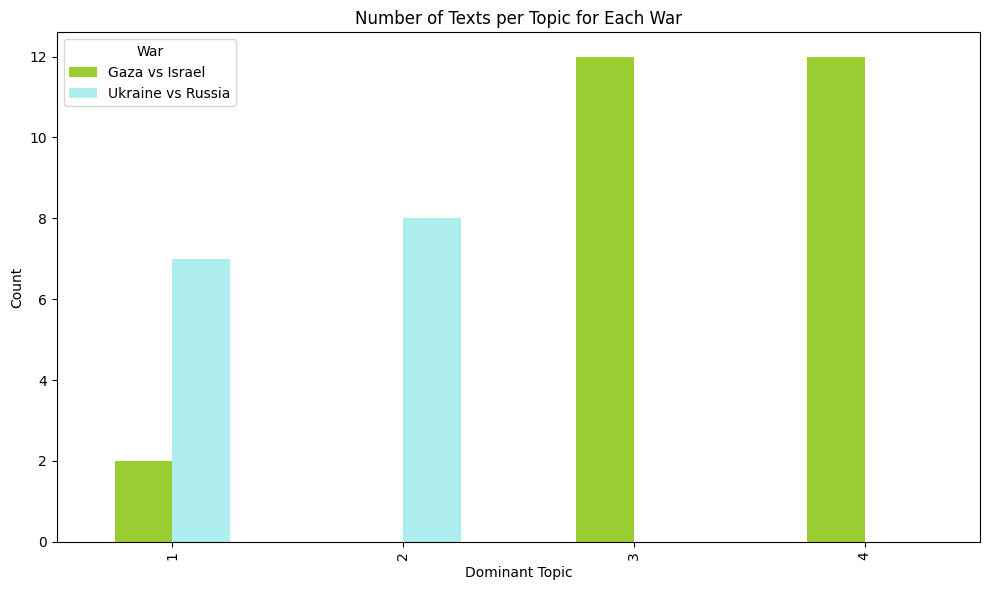

In [27]:
# Count documents per (War, Topic)
counts = dataframe_all.groupby(["Dominant Topic", "War"]).size().unstack(fill_value=0)

# Plot
counts.plot(kind="bar", figsize=(10,6), color = ['yellowgreen','paleturquoise'])

plt.title("Number of Texts per Topic for Each War")
plt.xlabel("Dominant Topic")
plt.ylabel("Count")
plt.legend(title="War")
plt.tight_layout()
plt.show()

In [28]:
np.random.seed(RANDOM_STATE)
vectorizer = TfidfVectorizer(max_df=0.9, min_df=2, stop_words='english') 
X = vectorizer.fit_transform(dataframe_all['Text'])
vocab = vectorizer.get_feature_names_out()
tfidf_dataframe = pd.DataFrame(X.toarray(), columns=vocab)
dataframe_all['Top words tf-idf'] = dataframe_all.index.to_series().apply(lambda i: tfidf_dataframe.iloc[i].nlargest(20).index.tolist())

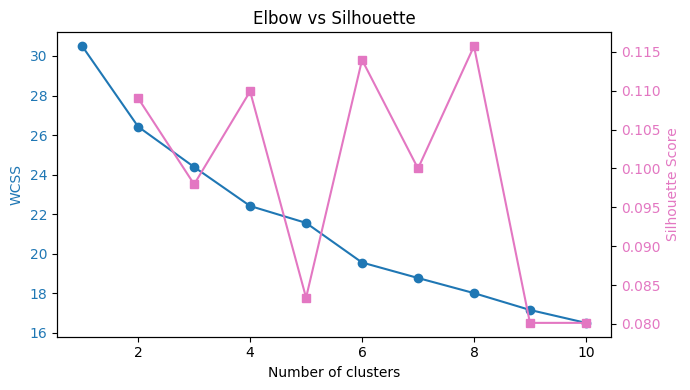

In [29]:
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters = i, init='k-means++', max_iter=300, random_state=0)
    kmeans.fit(X),
    wcss.append(kmeans.inertia_)
    
silhouette_scores = []
for k in range(2,11):
    kmeans = KMeans(n_clusters = k, init='k-means++', max_iter=300, random_state=0)
    labels = kmeans.fit_predict(X)
    sil = silhouette_score(X,labels)
    silhouette_scores.append(sil)

    
fig, ax1 = plt.subplots(figsize=(7, 4))

ax1.plot(range(1, 11), wcss, color='tab:blue', marker='o', label='WCSS')
ax1.set_xlabel('Number of clusters')
ax1.set_ylabel('WCSS', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(range(2, 11), silhouette_scores, color='tab:pink', marker='s', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='tab:pink')
ax2.tick_params(axis='y', labelcolor='tab:pink')

plt.title('Elbow vs Silhouette')
fig.tight_layout()
plt.show()

In [30]:
best_k = 5

kmeans = KMeans(n_clusters = best_k, n_init= 10, random_state=RANDOM_STATE)
labels = kmeans.fit_predict(X)
dataframe_all['Cluster'] = labels

def top_terms_per_cluster(model, vocab, topn=50):    
    centers = model.cluster_centers_  

    for c in range(centers.shape[0]):  
        top_idx = centers[c].argsort()[-topn:][::-1]  
        terms = [vocab[i] for i in top_idx]  
        print(f"\nCluster {c} top terms:\n  " + "  ".join(terms))  

print("\nTop words per cluster:")
top_terms_per_cluster(kmeans, vocab)  


Top words per cluster:

Cluster 0 top terms:
  ohchr  kill  detention  arrest  torture  incident  hostility  defense  illtreatment  strike  reportedly  death  escalation  injure  boy  palestine  arbitrary  crime  context  charge  injury  lethal  defender  demonstration  girl  advocate  detain  freedom  ammunition  release  live  mr  unlawful  para  journalist  allegation  regard  excessive  fence  close  alleged  genderbased  damage  relation  soldier  punishment  sentence  facto  bearer  detainee

Cluster 1 top terms:
  torture  sexual  detention  conflict  facility  conflictrelated  casualty  internment  kill  detainee  medical  illtreatment  girl  frontline  injure  armed  interview  art  treatment  accountability  interviewee  sudan  explosive  occupation  ihrl  occur  harm  individual  condition  education  boy  control  rape  weapon  munition  damage  collaboration  national  detain  captivity  missile  beating  home  school  police  citizenship  liberty  oblast  hostility  resi

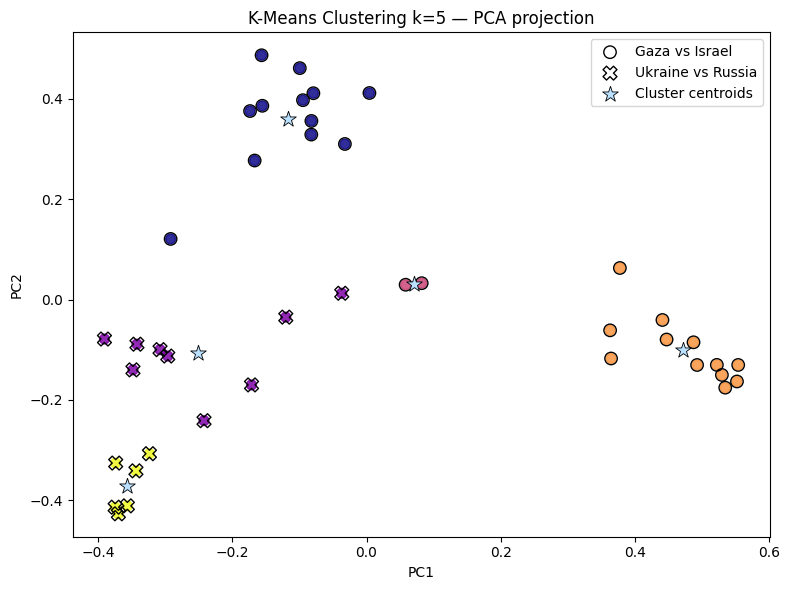

In [31]:
# PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca.fit_transform(X.toarray())

type_A_idx = np.where(dataframe_all['War'] == 'Gaza vs Israel')[0]
type_B_idx = np.where(dataframe_all['War'] == 'Ukraine vs Russia')[0]

plt.figure(figsize=(8,6))

# Plot all points
plt.scatter(
    X_2d[:,0],
    X_2d[:,1],
    c=labels,               
    cmap="plasma",
    s=50,
    alpha=0.85
)

# Overlay markers for war types to distinguish between war on the plot
plt.scatter(
    X_2d[type_A_idx,0],
    X_2d[type_A_idx,1],
    facecolors='none', 
    edgecolors='black',
    marker='o',
    s=80,
    label='Gaza vs Israel'
)
plt.scatter(
    X_2d[type_B_idx,0],
    X_2d[type_B_idx,1],
    facecolors='none', 
    edgecolors='black',
    marker='X',
    s=100,
    label='Ukraine vs Russia'
)

# Centroids
centroids_2d = pca.transform(kmeans.cluster_centers_)
plt.scatter(
    centroids_2d[:,0],
    centroids_2d[:,1],
    c="#BAE1FF",
    s=140,
    edgecolors="black",
    linewidth=0.6,
    marker="*",
    label="Cluster centroids"
)

plt.title(f"K-Means Clustering k={best_k} — PCA projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.show()

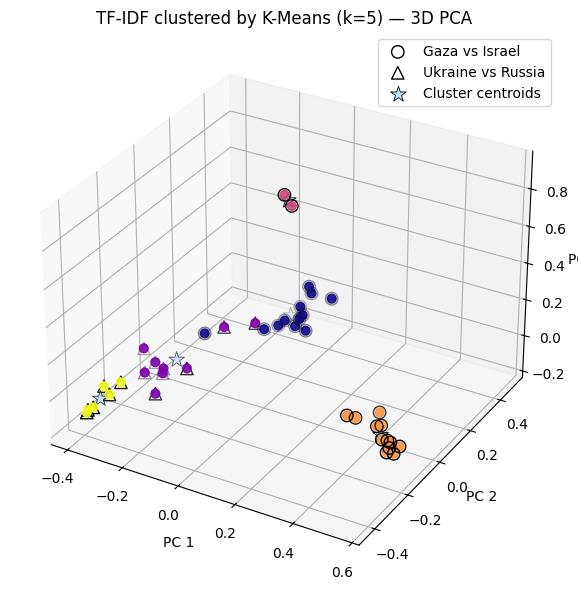

In [32]:
# PCA to 3 components
pca3 = PCA(n_components=3, random_state=RANDOM_STATE)
X_3d = pca3.fit_transform(X.toarray())

# Get indices by War category
gaza_idx = np.where(dataframe_all['War'] == 'Gaza vs Israel')[0]
ukraine_idx = np.where(dataframe_all['War'] == 'Ukraine vs Russia')[0]

# 3D figure
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

# Plot all points
scatter_all = ax.scatter(
    X_3d[:,0], X_3d[:,1], X_3d[:,2],
    c=labels,
    cmap='plasma',
    s=40,
    alpha=0.9
)

# Overlay war type markers
ax.scatter(
    X_3d[gaza_idx,0], X_3d[gaza_idx,1], X_3d[gaza_idx,2],
    facecolors='none',
    edgecolors='black',
    marker='o',
    s=80,
    label='Gaza vs Israel'
)
ax.scatter(
    X_3d[ukraine_idx,0], X_3d[ukraine_idx,1], X_3d[ukraine_idx,2],
    facecolors='none',
    edgecolors='black',
    marker='^',
    s=80,
    label='Ukraine vs Russia'
)

# Plot centroids
centroids_3d = pca3.transform(kmeans.cluster_centers_)
ax.scatter(
    centroids_3d[:,0], centroids_3d[:,1], centroids_3d[:,2],
    c="#BAE1FF",
    s=140,
    edgecolors="black",
    linewidth=0.6,
    marker="*",
    label="Cluster centroids"
)

ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.set_zlabel("PC 3")
ax.set_title(f"TF-IDF clustered by K-Means (k={best_k}) — 3D PCA")
ax.legend()

plt.tight_layout()
plt.show()

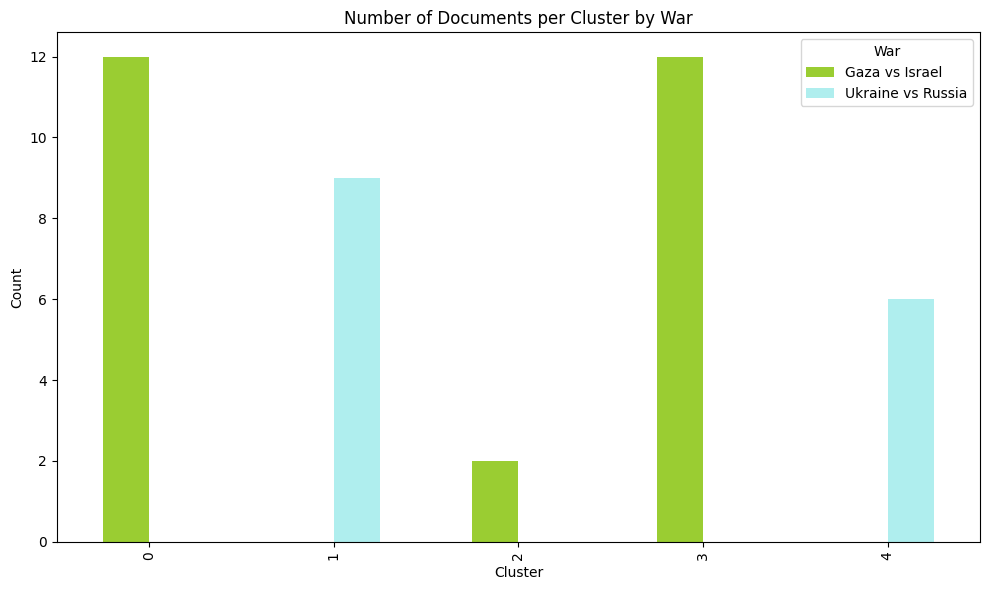

In [33]:
counts = dataframe_all.groupby(['Cluster', 'War']).size().unstack(fill_value=0)
counts.plot(kind='bar', figsize=(10,6), color = ['yellowgreen', 'paleturquoise'])
plt.title("Number of Documents per Cluster by War")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.legend(title="War")
plt.tight_layout()
plt.show()